# 📊 서울시 자치구별 CCTV 설치 현황 데이터 분석
> **데이터 출처**: 서울 열린데이터광장 (Seoul Open Data)  
> **분석 파일**: `CCTV/data/01. CCTV_in_Seoul.csv`

---

### 💡 학습 목표
1. **`pandas` 라이브러리를 활용한 CSV 파일 로드**: 한글 인코딩 및 경로 설정의 원리 이해
2. **기본 데이터 탐색 (EDA)**: 데이터 크기, 컬럼 구조, 결측치 및 자료형 확인
3. **컬럼명 정제**: 이후 인구수 데이터와의 병합(`merge`)을 위한 컬럼명 통일 (`'기관명'` → `'구별'`)
4. **기초 정렬 분석**: 서울시 자치구 중 CCTV 설치 대수가 가장 많은 구와 적은 구 확인

## 1. 라이브러리 임포트 (Import)

데이터 분석과 표(DataFrame) 조작에 가장 핵심적인 `pandas`와 수치 연산용 `numpy`를 불러옵니다.

In [2]:
# [셀 의도] pandas와 numpy 라이브러리를 불러옵니다.
import pandas as pd
import numpy as np

print("✅ 라이브러리 불러오기 완료! (Pandas 버전:", pd.__version__, ")")

✅ 라이브러리 불러오기 완료! (Pandas 버전: 3.0.6 )


## 2. CCTV CSV 데이터 파일 불러오기 (`pd.read_csv`)

### 📌 파일 경로(Path) 이해하기
- 현재 주피터 노트북 파일이 **`CCTV/`** 폴더 안에 위치해 있습니다.
- 따라서 `01. CCTV_in_Seoul.csv` 파일의 상대 경로는 **`data/01. CCTV_in_Seoul.csv`**가 됩니다.
  *(만약 프로젝트 최상위 루트 디렉터리에서 실행할 경우에는 `CCTV/data/01. CCTV_in_Seoul.csv`로 지정합니다)*

### 📌 한글 인코딩(`encoding`) 옵션
- 한글이 포함된 CSV 파일을 읽을 때는 인코딩 방식(`utf-8`, `cp949`, `euc-kr`)이 중요합니다.
- 본 데이터는 **`utf-8`**로 인코딩되어 있어 `encoding='utf-8'`을 명시하거나 기본값으로 안정적으로 로드할 수 있습니다.

In [3]:
# [셀 의도] CCTV 폴더 내부에서 data 폴더의 CSV 파일을 불러옵니다.
# 1. 파일 상대 경로 지정
csv_path = 'data/01. CCTV_in_Seoul.csv'

# 2. 판다스로 CSV 파일 읽어오기
cctv_seoul = pd.read_csv(csv_path, encoding='utf-8')

# 3. 데이터의 상위 5개 행(head) 확인
print("✅ '01. CCTV_in_Seoul.csv' 불러오기 성공!")
cctv_seoul.head()
cctv_seoul.tail()

✅ '01. CCTV_in_Seoul.csv' 불러오기 성공!


,기관명,소계,2013년도 이전,2014년,2015년,2016년
20,용산구,1624,1368,218,112,398
21,은평구,1873,1138,224,278,468
22,종로구,1002,464,314,211,630
23,중구,671,413,190,72,348
24,중랑구,660,509,121,177,109


## 3. 데이터 구조 및 기본 정보 확인 (Data Inspection)

불러온 데이터가 정상적인지 확인하기 위해 다음 3가지를 점검합니다:
1. `shape`: 전체 행과 열의 개수 (서울시 자치구 25개이므로 25행이어야 함)
2. `columns`: 컬럼 이름 목록
3. `info()`: 결측치(Null) 유무 및 각 컬럼의 데이터 타입(dtype)

In [4]:
# [셀 의도] 데이터의 크기, 컬럼 목록, 결측치 및 자료형을 확인합니다.
print("=" * 60)
print(f"1. 데이터 크기: {cctv_seoul.shape[0]}개 구(행), {cctv_seoul.shape[1]}개 컬럼(열)")
print("=" * 60)

print("\n2. 컬럼명 목록:")
for idx, col in enumerate(cctv_seoul.columns):
    print(f"   [{idx}] {col}")

print("\n3. 데이터 요약 정보 (.info()):")
cctv_seoul.info()

1. 데이터 크기: 25개 구(행), 6개 컬럼(열)

2. 컬럼명 목록:
   [0] 기관명
   [1] 소계
   [2] 2013년도 이전
   [3] 2014년
   [4] 2015년
   [5] 2016년

3. 데이터 요약 정보 (.info()):
<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   기관명        25 non-null     str  
 1   소계         25 non-null     int64
 2   2013년도 이전  25 non-null     int64
 3   2014년      25 non-null     int64
 4   2015년      25 non-null     int64
 5   2016년      25 non-null     int64
dtypes: int64(5), str(1)
memory usage: 1.3 KB


## 4. 컬럼명 변경 (`rename`): `'기관명'` → `'구별'`

### 💡 왜 컬럼명을 변경해야 할까요?
- 현재 자치구 이름이 담긴 컬럼명이 **`'기관명'`**으로 되어 있습니다.
- 이후 실습에서 불러올 **서울시 인구수 데이터(`01. population_in_Seoul.xls`)**에는 자치구 컬럼명이 **`'구별'`**로 되어 있습니다.
- 두 데이터프레임을 하나로 합치는 병합(Merge/Join) 작업을 원활하게 수행하기 위해, 기준이 되는 공통 키 컬럼명을 미리 **`'구별'`**로 통일해 둡니다.

In [5]:
# [셀 의도] '기관명' 컬럼의 이름을 '구별'로 변경합니다.
cctv_seoul.rename(columns={'기관명': '구별'}, inplace=True)

# 변경된 결과 확인 (상위 3개 행)
cctv_seoul.head(3)

,구별,소계,2013년도 이전,2014년,2015년,2016년
0,강남구,2780,1292,430,584,932
1,강동구,773,379,99,155,377
2,강북구,748,369,120,138,204


## 5. 데이터 정렬 및 기본 분석 (`sort_values`)

CCTV 총 설치 대수(`'소계'`)를 기준으로 서울시 25개 자치구를 오름차순/내림차순으로 정렬해 봅니다:
- **CCTV 설치 대수가 가장 많은 상위 5개 구**
- **CCTV 설치 대수가 가장 적은 하위 5개 구**

In [6]:
# [셀 의도] '소계' 컬럼을 기준으로 정렬하여 상위 및 하위 5개 자치구를 비교합니다.
print("🔝 [CCTV 설치 대수가 가장 많은 자치구 TOP 5]")
display(cctv_seoul.sort_values(by='소계', ascending=False).head(5))

print("\n🔻 [CCTV 설치 대수가 가장 적은 자치구 TOP 5]")
display(cctv_seoul.sort_values(by='소계', ascending=True).head(5))

🔝 [CCTV 설치 대수가 가장 많은 자치구 TOP 5]


,구별,소계,2013년도 이전,2014년,2015년,2016년
0,강남구,2780,1292,430,584,932
18,양천구,2034,1843,142,30,467
14,서초구,1930,1406,157,336,398
21,은평구,1873,1138,224,278,468
20,용산구,1624,1368,218,112,398



🔻 [CCTV 설치 대수가 가장 적은 자치구 TOP 5]


,구별,소계,2013년도 이전,2014년,2015년,2016년
9,도봉구,485,238,159,42,386
12,마포구,574,314,118,169,379
17,송파구,618,529,21,68,463
24,중랑구,660,509,121,177,109
23,중구,671,413,190,72,348


In [7]:
display(cctv_seoul.sort_values(by='소계', ascending=True).tail())

,구별,소계,2013년도 이전,2014년,2015년,2016년
20,용산구,1624,1368,218,112,398
21,은평구,1873,1138,224,278,468
14,서초구,1930,1406,157,336,398
18,양천구,2034,1843,142,30,467
0,강남구,2780,1292,430,584,932


## 6. 최근 증가율 계산 (응용 실습)

2014년부터 2016년까지 최근 3년간 설치된 CCTV 대수가 2013년 이전 설치 대수 대비 얼마나 증가했는지 **`'최근증가율'`** 컬럼을 만들어 계산해 봅니다.

$$\text{최근증가율} = \frac{2014\text{년} + 2015\text{년} + 2016\text{년}}{2013\text{년도 이전}} \times 100$$

In [8]:
# [셀 의도] 최근 3개년(2014~2016년) CCTV 설치 증가율을 계산하여 신규 컬럼으로 추가합니다.
cctv_seoul['최근증가율'] = (
    (cctv_seoul['2016년'] + cctv_seoul['2015년'] + cctv_seoul['2014년']) / cctv_seoul['2013년도 이전']
) * 100

print("📈 [최근 3년간 CCTV 증가율이 가장 높은 자치구 TOP 5]")
display(cctv_seoul.sort_values(by='최근증가율', ascending=False).head(5))

📈 [최근 3년간 CCTV 증가율이 가장 높은 자치구 TOP 5]


,구별,소계,2013년도 이전,2014년,2015년,2016년,최근증가율
22,종로구,1002,464,314,211,630,248.922414
9,도봉구,485,238,159,42,386,246.638655
12,마포구,574,314,118,169,379,212.101911
8,노원구,1265,542,57,451,516,188.929889
1,강동구,773,379,99,155,377,166.490765


## 7. 요약 및 다음 단계 안내

| 주요 명령어 | 코드 형태 | 역할 및 의도 |
| :--- | :--- | :--- |
| **CSV 파일 읽기** | `pd.read_csv('data/01. CCTV_in_Seoul.csv', encoding='utf-8')` | CSV 파일을 표 형태(DataFrame)로 메모리에 로드 |
| **상위 행 조회** | `df.head(n)` | 처음 $n$개 행을 출력하여 데이터 형태 점검 |
| **컬럼명 변경** | `df.rename(columns={'기관명': '구별'}, inplace=True)` | 추후 인구 데이터(`population`)와의 병합 키 통일 |
| **수치 정렬** | `df.sort_values(by='소계', ascending=False)` | 특정 컬럼 기준으로 순위 비교 및 탐색 |
| **파생 변수 생성** | `df['최근증가율'] = (...) * 100` | 새로운 분석 지표 계산 |

---
*다음 단계에서는 `01. population_in_Seoul.xls` 엑셀 데이터를 불러와 인구수 대비 CCTV 비율을 분석하고 시각화할 수 있습니다.*

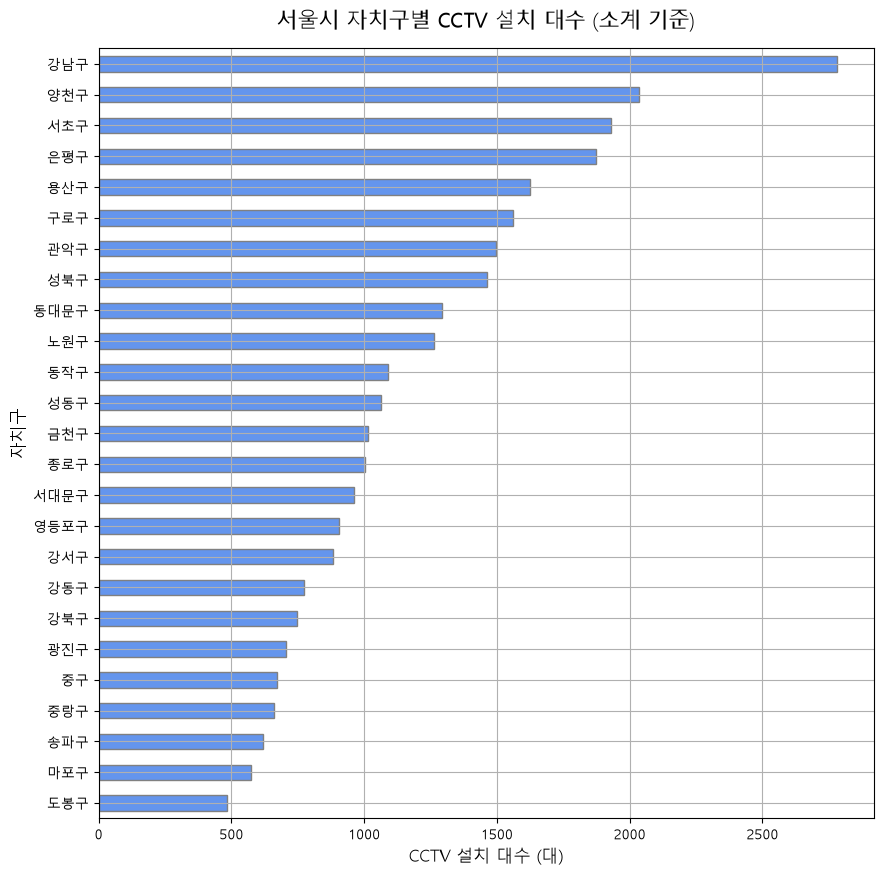

In [9]:
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정 (Windows 기본 맑은 고딕 & 마이너스 부호 깨짐 방지)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. '구별'을 인덱스로 지정 후 '소계' 컬럼 기준 정렬하여 수평 바 차트 생성
plt.figure(figsize=(10, 10))

# sort_values()를 해주면 가장 큰 값(강남구 등)이 맨 위쪽에 오게 됩니다.
cctv_seoul.set_index('구별')['소계'].sort_values().plot(
    kind='barh',
    grid=True,
    color='cornflowerblue',
    edgecolor='gray',
    figsize=(10, 10)
)

# 3. 차트 제목 및 라벨 설정
plt.title('서울시 자치구별 CCTV 설치 대수 (소계 기준)', fontsize=15, pad=15)
plt.xlabel('CCTV 설치 대수 (대)', fontsize=12)
plt.ylabel('자치구', fontsize=12)

plt.show()


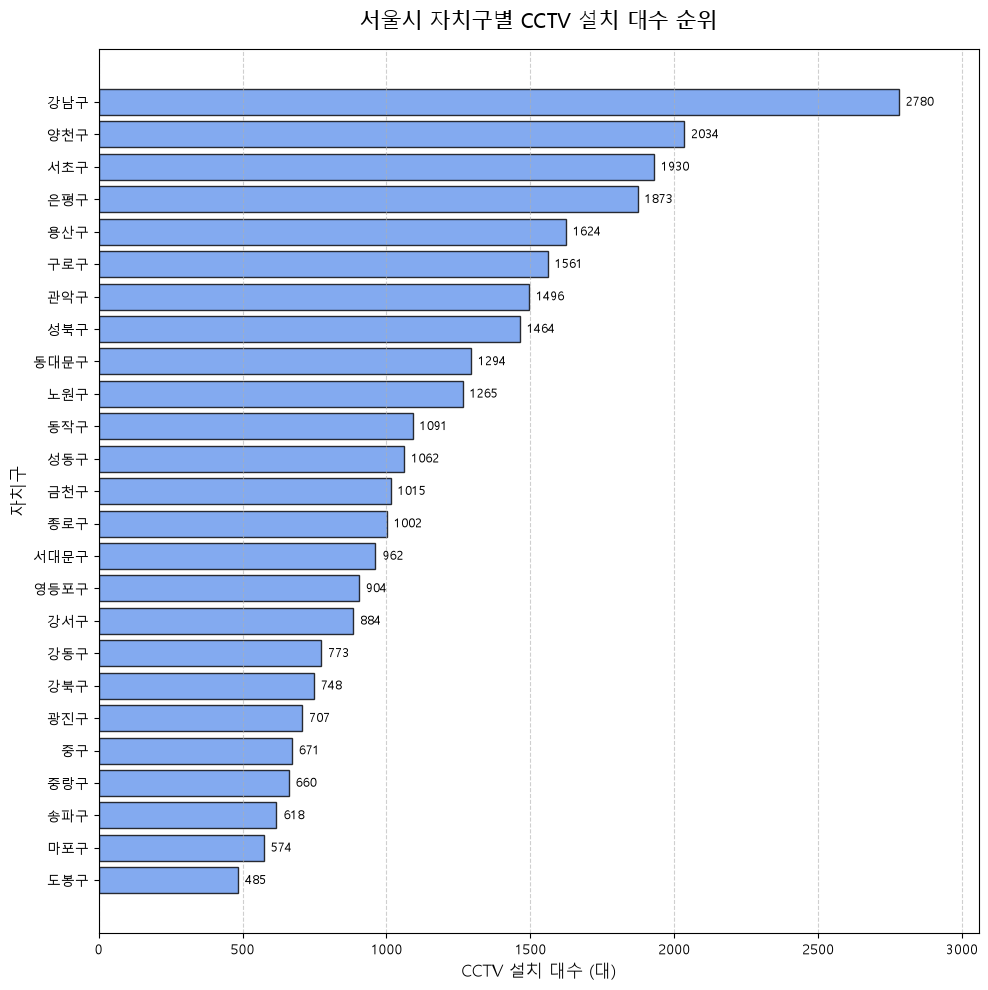

In [10]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 10))

# '소계' 기준 오름차순 정렬 (맨 위에 최고값 위치)
data_sorted = cctv_seoul.set_index('구별')['소계'].sort_values()

# 수평 바 차트 그리기
bars = ax.barh(data_sorted.index, data_sorted.values, color='cornflowerblue', edgecolor='black', alpha=0.8)

# 막대 끝에 수치(라벨) 자동 표시
ax.bar_label(bars, padding=5, fmt='%d', fontsize=9)

# 스타일 설정
ax.set_title('서울시 자치구별 CCTV 설치 대수 순위', fontsize=15, pad=15)
ax.set_xlabel('CCTV 설치 대수 (대)', fontsize=12)
ax.set_ylabel('자치구', fontsize=12)
ax.grid(True, axis='x', linestyle='--', alpha=0.6)
ax.set_xlim(0, data_sorted.max() * 1.1)  # 라벨이 잘리지 않도록 x축 여유 확보

plt.tight_layout()
plt.show()


In [14]:
import pandas as pd

# 1. 파일 상대 경로 지정
pop_path = 'data/01. population_in_Seoul.xls'

# 2. 엑셀 파일 로드
# - header=2: 3번째 행(인덱스 2)을 컬럼명으로 인식하여 상단 불필요한 제목 행 제외
# - usecols='B, D, G, J, N': 분석에 필요한 핵심 열만 선택
#   (B: 자치구, D: 전체인구, G: 한국인, J: 외국인, N: 65세이상고령자)
pop_seoul = pd.read_excel(pop_path, header=2, usecols='B, D, G, J, N')

# 3. CCTV 데이터프레임과 병합('구별' 기준)을 위해 컬럼명 변경
pop_seoul.rename(columns={
    pop_seoul.columns[0]: '구별',
    pop_seoul.columns[1]: '인구수',
    pop_seoul.columns[2]: '한국인',
    pop_seoul.columns[3]: '외국인',
    pop_seoul.columns[4]: '고령자'
}, inplace=True)

# 4. 상위 5개 행 확인
pop_seoul.head()


,구별,인구수,한국인,외국인,고령자
0,합계,10197604.0,9926968.0,270636.0,1321458.0
1,종로구,162820.0,153589.0,9231.0,25425.0
2,중구,133240.0,124312.0,8928.0,20764.0
3,용산구,244203.0,229456.0,14747.0,36231.0
4,성동구,311244.0,303380.0,7864.0,39997.0


In [12]:
pop_seoul.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   구별      26 non-null     str    
 1   인구수     26 non-null     float64
 2   한국인     26 non-null     float64
 3   외국인     26 non-null     float64
 4   고령자     26 non-null     float64
dtypes: float64(4), str(1)
memory usage: 1.2 KB


In [13]:
cctv_seoul.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   구별         25 non-null     str    
 1   소계         25 non-null     int64  
 2   2013년도 이전  25 non-null     int64  
 3   2014년      25 non-null     int64  
 4   2015년      25 non-null     int64  
 5   2016년      25 non-null     int64  
 6   최근증가율      25 non-null     float64
dtypes: float64(1), int64(5), str(1)
memory usage: 1.5 KB


In [15]:
# 0번 행 삭제 후 인덱스 0부터 재정렬
pop_seoul.drop([0], inplace=True)
pop_seoul.reset_index(drop=True, inplace=True)

pop_seoul.head()


,구별,인구수,한국인,외국인,고령자
0,종로구,162820.0,153589.0,9231.0,25425.0
1,중구,133240.0,124312.0,8928.0,20764.0
2,용산구,244203.0,229456.0,14747.0,36231.0
3,성동구,311244.0,303380.0,7864.0,39997.0
4,광진구,372164.0,357211.0,14953.0,42214.0


In [18]:
# '구별' 값이 비어있는(NaN) 행을 찾아 안전하게 삭제
pop_seoul.dropna(subset=['구별'], inplace=True)

# 끝부분 5개 행 확인
pop_seoul.tail()


,구별,인구수,한국인,외국인,고령자
20,관악구,525515.0,507203.0,18312.0,68082.0
21,서초구,450310.0,445994.0,4316.0,51733.0
22,강남구,570500.0,565550.0,4950.0,63167.0
23,송파구,667483.0,660584.0,6899.0,72506.0
24,강동구,453233.0,449019.0,4214.0,54622.0


In [16]:
# '구별' 컬럼이 비어있는(NaN) 행 자동 제거
pop_seoul.dropna(subset=['구별'], inplace=True)

# 25개 자치구만 남았는지 행 개수 확인 (25가 출력되면 정상)
print("남은 자치구 개수:", len(pop_seoul))
pop_seoul.tail()


남은 자치구 개수: 25


,구별,인구수,한국인,외국인,고령자
20,관악구,525515.0,507203.0,18312.0,68082.0
21,서초구,450310.0,445994.0,4316.0,51733.0
22,강남구,570500.0,565550.0,4950.0,63167.0
23,송파구,667483.0,660584.0,6899.0,72506.0
24,강동구,453233.0,449019.0,4214.0,54622.0


In [19]:
# '구별' 컬럼을 기준으로 두 데이터프레임 병합
data_result = pd.merge(cctv_seoul, pop_seoul, on='구별')

# 병합된 데이터프레임 상위 5개 행 확인
data_result.head()


,구별,소계,2013년도 이전,2014년,2015년,2016년,최근증가율,인구수,한국인,외국인,고령자
0,강남구,2780,1292,430,584,932,150.619195,570500.0,565550.0,4950.0,63167.0
1,강동구,773,379,99,155,377,166.490765,453233.0,449019.0,4214.0,54622.0
2,강북구,748,369,120,138,204,125.203252,330192.0,326686.0,3506.0,54813.0
3,강서구,884,388,258,184,81,134.793814,603772.0,597248.0,6524.0,72548.0
4,관악구,1496,846,260,390,613,149.290780,525515.0,507203.0,18312.0,68082.0


In [20]:
# 전체 행과 열 개수 확인 (25개 구가 모두 포함되어 25행이어야 정상)
print("병합된 데이터 크기 (행, 열):", data_result.shape)


병합된 데이터 크기 (행, 열): (25, 11)


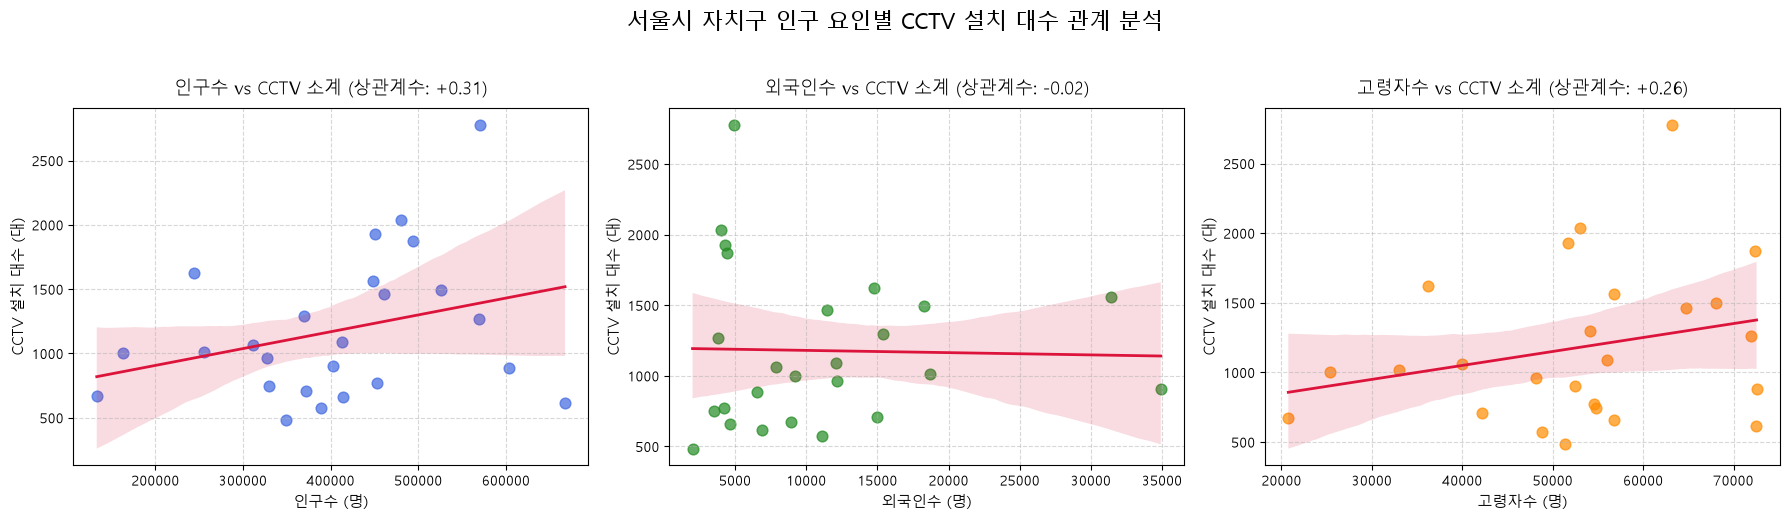

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 부호 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 1행 3열 서브플롯 생성
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) 인구수 vs CCTV 소계
sns.regplot(
    data=data_result, x='인구수', y='소계', ax=axes[0],
    color='royalblue', scatter_kws={'s': 60, 'alpha': 0.7}, line_kws={'color': 'crimson', 'linewidth': 2}
)
axes[0].set_title('인구수 vs CCTV 소계 (상관계수: +0.31)', fontsize=13, pad=10)
axes[0].set_xlabel('인구수 (명)', fontsize=11)
axes[0].set_ylabel('CCTV 설치 대수 (대)', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

# (2) 외국인수 vs CCTV 소계
sns.regplot(
    data=data_result, x='외국인', y='소계', ax=axes[1],
    color='forestgreen', scatter_kws={'s': 60, 'alpha': 0.7}, line_kws={'color': 'crimson', 'linewidth': 2}
)
axes[1].set_title('외국인수 vs CCTV 소계 (상관계수: -0.02)', fontsize=13, pad=10)
axes[1].set_xlabel('외국인수 (명)', fontsize=11)
axes[1].set_ylabel('CCTV 설치 대수 (대)', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)

# (3) 고령자수 vs CCTV 소계
sns.regplot(
    data=data_result, x='고령자', y='소계', ax=axes[2],
    color='darkorange', scatter_kws={'s': 60, 'alpha': 0.7}, line_kws={'color': 'crimson', 'linewidth': 2}
)
axes[2].set_title('고령자수 vs CCTV 소계 (상관계수: +0.26)', fontsize=13, pad=10)
axes[2].set_xlabel('고령자수 (명)', fontsize=11)
axes[2].set_ylabel('CCTV 설치 대수 (대)', fontsize=11)
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('서울시 자치구 인구 요인별 CCTV 설치 대수 관계 분석', fontsize=16, y=1.03)
plt.tight_layout()
plt.show()


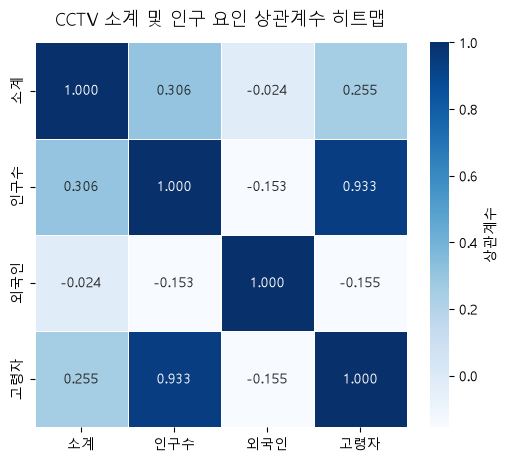

In [22]:
plt.figure(figsize=(6, 5))
corr_matrix = data_result[['소계', '인구수', '외국인', '고령자']].corr()

sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.3f', 
    cmap='Blues', 
    linewidths=0.5,
    cbar_kws={'label': '상관계수'}
)
plt.title('CCTV 소계 및 인구 요인 상관계수 히트맵', fontsize=13, pad=12)
plt.show()


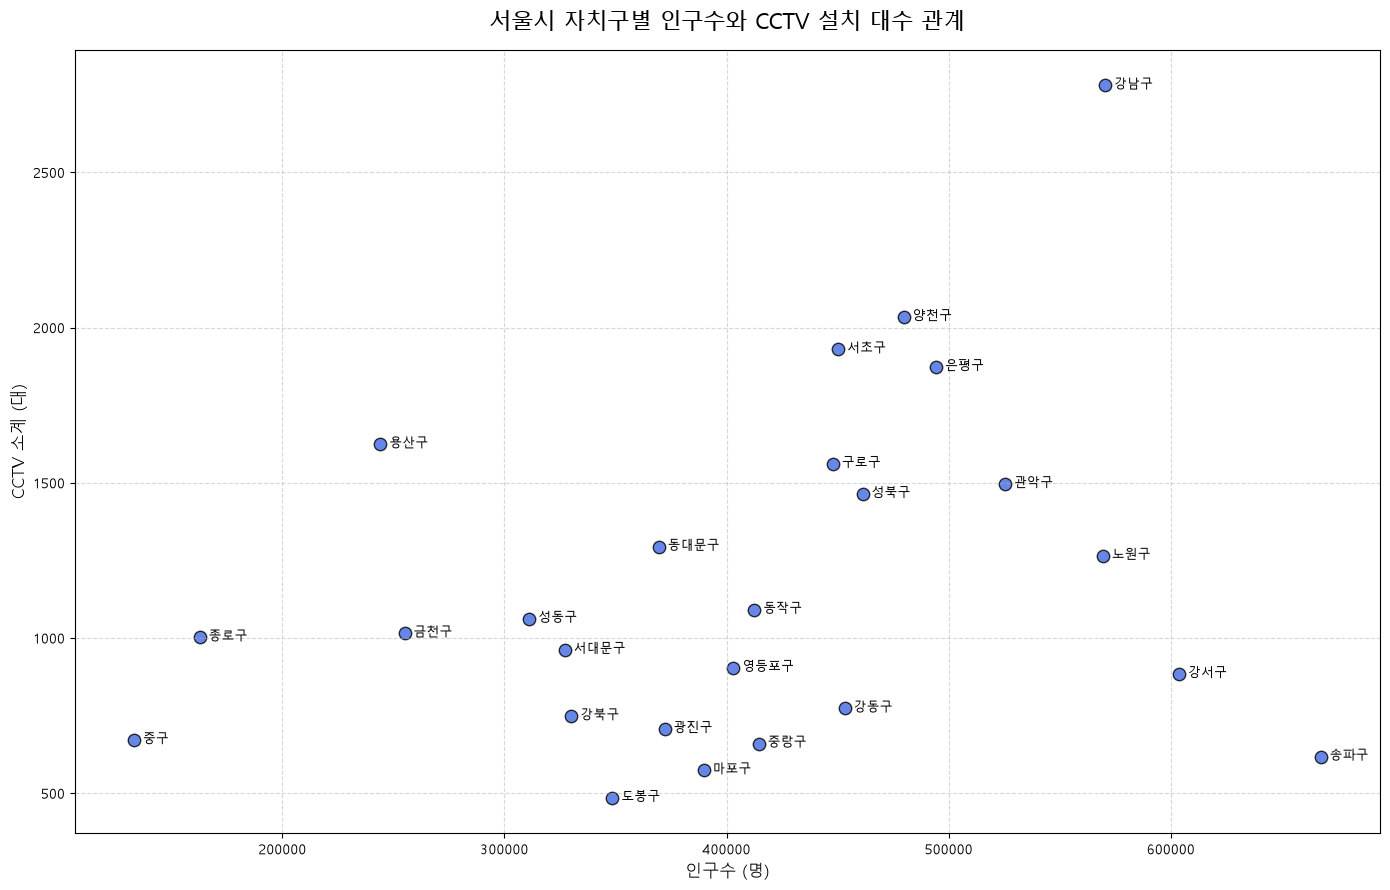

In [23]:
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정 (Windows 맑은 고딕 & 마이너스 부호 깨짐 방지)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 그래프 크기 설정 (글자가 겹치지 않도록 넉넉하게 지정)
plt.figure(figsize=(14, 9))

# 3. 산점도(Scatter Plot) 그리기
plt.scatter(
    data_result['인구수'], 
    data_result['소계'], 
    s=80, 
    c='royalblue', 
    edgecolors='black', 
    alpha=0.8
)

# 4. 각 점 옆에 '구별' 이름 출력하기 (plt.text)
# 점과 글자가 완전히 겹치지 않도록 x축으로 살짝(+4000) 띄워 출력합니다.
for _, row in data_result.iterrows():
    plt.text(
        row['인구수'] + 4000, 
        row['소계'] - 10, 
        row['구별'], 
        fontsize=9.5
    )

# 5. 그래프 타이틀, 축 라벨, 그리드 설정
plt.title('서울시 자치구별 인구수와 CCTV 설치 대수 관계', fontsize=16, pad=15)
plt.xlabel('인구수 (명)', fontsize=12)
plt.ylabel('CCTV 소계 (대)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


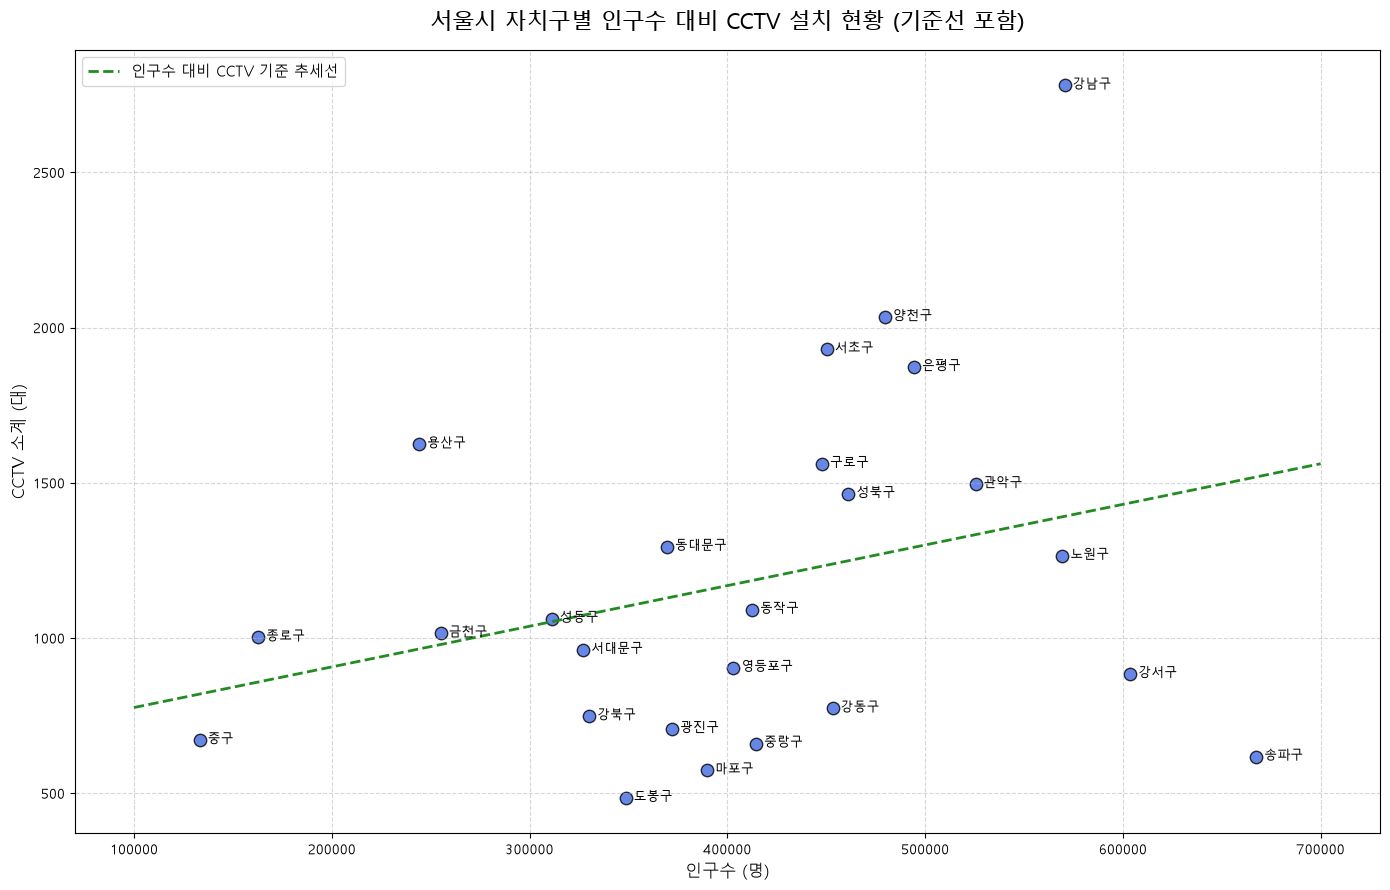

In [24]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 인구수와 소계 간의 1차 선형 회귀선 계수 계산 (기울기, 절편)
fp1 = np.polyfit(data_result['인구수'], data_result['소계'], 1)
f1 = np.poly1d(fp1)

# x축 범위(최소 인구수 ~ 최대 인구수) 생성
fx = np.linspace(100000, 700000, 100)

# 2. 시각화
plt.figure(figsize=(14, 9))
plt.scatter(data_result['인구수'], data_result['소계'], s=80, c='royalblue', edgecolors='black', alpha=0.8)

# 회귀 기준선(점선) 추가
plt.plot(fx, f1(fx), ls='dashed', lw=2, color='forestgreen', label='인구수 대비 CCTV 기준 추세선')

# 자치구 라벨 표시
for _, row in data_result.iterrows():
    plt.text(row['인구수'] + 4000, row['소계'] - 10, row['구별'], fontsize=9.5)

plt.title('서울시 자치구별 인구수 대비 CCTV 설치 현황 (기준선 포함)', fontsize=16, pad=15)
plt.xlabel('인구수 (명)', fontsize=12)
plt.ylabel('CCTV 소계 (대)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()
